In [ ]:
from greapy import GREA

# Create an instance of the GREA model
cosmo = GREA()
cosmo

In [ ]:
cosmo.H0,100*cosmo.h

In [ ]:
cosmo.Omega_m

In [106]:
cosmo.Omega_bc

0.3137721026737606

<Axes: xlabel='Redshift $z$', ylabel='$D/D^{\\Lambda\\rm CDM}$'>

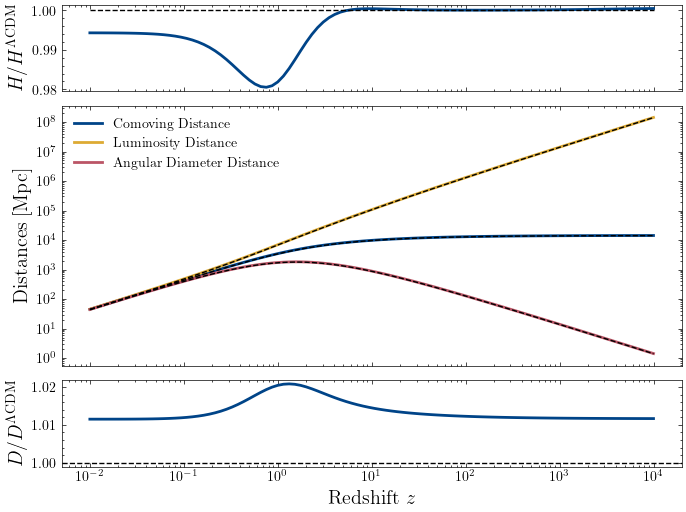

In [124]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots 
plt.style.use(['science','high-contrast'])
z=np.logspace(-2, 4, 100)

def plot_distances(z,model):
    
    from astropy.cosmology import FlatLambdaCDM
    lcdm = FlatLambdaCDM(H0=100*model.h, Om0=model.Omega_bc,Ob0=model.omega_b/model.h**2, Tcmb0=2.7259, Neff=3.044)
    
    fig,(ax_H,ax_obs,ax_res)=plt.subplots(3,1,sharex=True,figsize=(8, 6),gridspec_kw={'height_ratios': [1 ,3, 1],'hspace': 0.1 })
    
    for m, kwargs in zip([model, lcdm], [{'lw': 2}, {'linestyle': '--', 'c': 'k', 'lw': 1.}]):
        ax_H.plot(z, m.H(z)/lcdm.H(z).value, **kwargs)
        ax_obs.plot(z, m.comoving_distance(z), label='Comoving Distance',**kwargs)
        ax_obs.plot(z, m.luminosity_distance(z), label='Luminosity Distance',**kwargs)
        ax_obs.plot(z, m.angular_diameter_distance(z), label='Angular Diameter Distance',**kwargs)
        if m is model: ax_obs.legend()
    ax_res.plot(z, model.comoving_distance(z)/lcdm.comoving_distance(z).value,lw=2.)
    ax_res.axhline(1, color='k', lw=1, ls='--')
    ax_obs.loglog()
    ax_H.set_ylabel(r'$H/H^{\Lambda\rm CDM}$',fontsize='x-large')
    ax_obs.set_ylabel('Distances [Mpc]', fontsize='x-large')
    ax_res.set_ylabel(r'$D/D^{\Lambda\rm CDM}$', fontsize='x-large')
    ax_res.set_xlabel('Redshift $z$',fontsize='x-large')
    return plt.gca()
plot_distances(z, cosmo)

``GREApy`` can also compute the corresponding values of the sound horizon at recombination $r_s(z_{\rm rec})$ and drag epoch $r_d\equiv r_s(z_{\rm drag})$ 

In [125]:
cosmo.rs_rec,cosmo.rdrag

(144.5055213020333, 147.07705249598033)

In [89]:
100*cosmo.thetastar

1.0279483731713353

That's it! You've got everything you need to start sampling the posterior distribution of GREA and reproduce our analysis!